In [ ]:
!pip install haversine

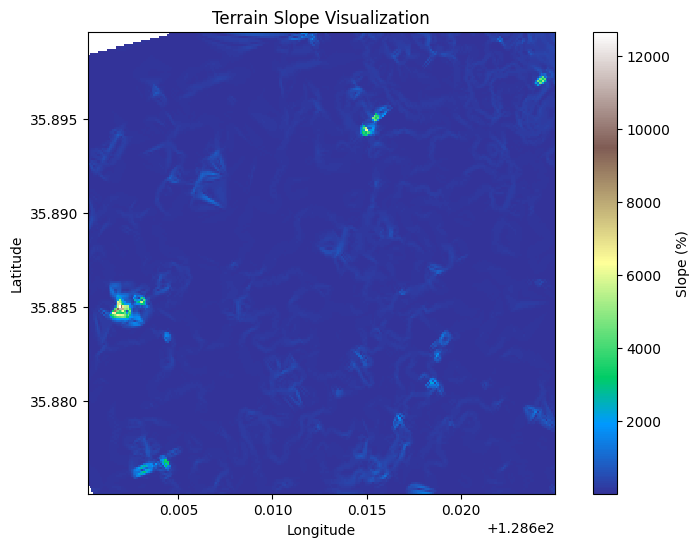

In [ ]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import griddata
from haversine import haversine, Unit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 데이터 로드
## 주의: 데이터가 한글로 되어 있기 때문에 encoding='euckr' 없으면 column 글자 깨짐
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')

# 데이터를 WGS 84 좌표계로 변환
elevation_points = elevation_points.to_crs(epsg=4326)
elevation_contours = elevation_contours.to_crs(epsg=4326)

# 등고선에서 고도 정보 추출 및 포인트로 변환
contour_points = elevation_contours.geometry.apply(lambda x: np.array(x.coords))
contour_elevations = np.repeat(elevation_contours['등고수치'], contour_points.apply(len))
contour_points = np.concatenate(contour_points.values)

# 표고점 데이터와 등고선 데이터 결합
all_points = np.vstack([contour_points, np.array(list(zip(elevation_points.geometry.x, elevation_points.geometry.y)))])
all_elevations = np.concatenate([contour_elevations, elevation_points['수치'].values])

# 각 방향의 실제 거리 계산
x_min, y_min, x_max, y_max = elevation_points.total_bounds
distance_x = haversine((y_min, x_min), (y_min, x_max), unit=Unit.METERS)
distance_y = haversine((y_min, x_min), (y_max, x_min), unit=Unit.METERS)

# 10m 간격으로 셀 수 계산
num_x_cells = int(distance_x / 10)
num_y_cells = int(distance_y / 10)

# 그리드 생성
## method 종류: 'nearest', 'linear', 'cubic'
## method='linear'는 선형 보간 방식을 사용한다는 것을 의미.
## 이 방법은 주변 점들 사이의 선형적인 관계를 기반으로 중간 값을 추정. 이는 비교적 부드러운 고도 표면을 생성
grid_x, grid_y = np.mgrid[x_min:x_max:num_x_cells*1j, y_min:y_max:num_y_cells*1j]
# grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='linear')
grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='cubic')
# grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='nearest')

# 경사도 계산
x, y = np.gradient(grid_z, axis=(0, 1), edge_order=1)
slope = np.sqrt(x**2 + y**2)
slope_degrees = np.arctan(slope) * (180 / np.pi)
slope_percent = np.tan(np.radians(slope_degrees)) * 100  # 경사도 백분율

# 경사도 데이터와 해당 좌표를 하나의 배열로 저장
coordinates_and_slope = np.zeros(slope_percent.shape, dtype=[('latitude', float), ('longitude', float), ('slope_percent', float)])

# 배열 크기에 따른 반복문 조정
for i in range(slope_percent.shape[0]):  # y축 크기
    for j in range(slope_percent.shape[1]):  # x축 크기
        lat = y_min + (i + 0.5) * (y_max - y_min) / slope_percent.shape[0]
        lon = x_min + (j + 0.5) * (x_max - x_min) / slope_percent.shape[1]
        coordinates_and_slope[i, j] = (lat, lon, slope_percent[i, j])

# 경사도 데이터와 위도, 경도 범위를 함께 저장
np.savez('/content/slope_data.npz', slope_percent=slope_percent, x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max)

# 시각화
extent = [x_min, x_max, y_min, y_max]
plt.figure(figsize=(10, 6))
plt.title('Terrain Slope Visualization')
plt.imshow(slope_percent, extent=extent, cmap='terrain', interpolation='none')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Slope (%)')

# # 그리드 라인 추가
# # 세로줄
# for i in range(num_x_cells):
#     plt.axvline(x_min + i * (x_max - x_min) / num_x_cells, color='white', linestyle='-', linewidth=0.5)
# # 가로줄
# for j in range(num_y_cells):
#     plt.axhline(y_min + j * (y_max - y_min) / num_y_cells, color='white', linestyle='-', linewidth=0.5)

# plt.grid(False)  # 기본 그리드 비활성화

plt.show()

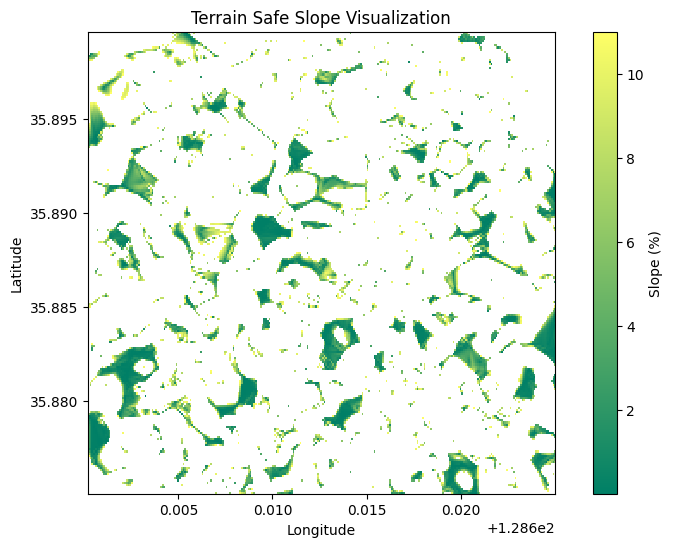

In [ ]:
# slope_percent에서 11 이하인 값만 강조
low_slope_mask = slope_percent <= 11
highlighted_slope = np.ma.masked_where(~low_slope_mask, slope_percent)  # 조건을 만족하지 않는 곳을 마스킹

# 11% 이하만 강조하여 표시
plt.figure(figsize=(10, 6))
plt.title('Terrain Safe Slope Visualization')
plt.imshow(highlighted_slope, extent=extent, cmap='summer', interpolation='none')  # 투명도를 조정하여 위에 겹쳐서 표시
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Slope (%)')
plt.show()

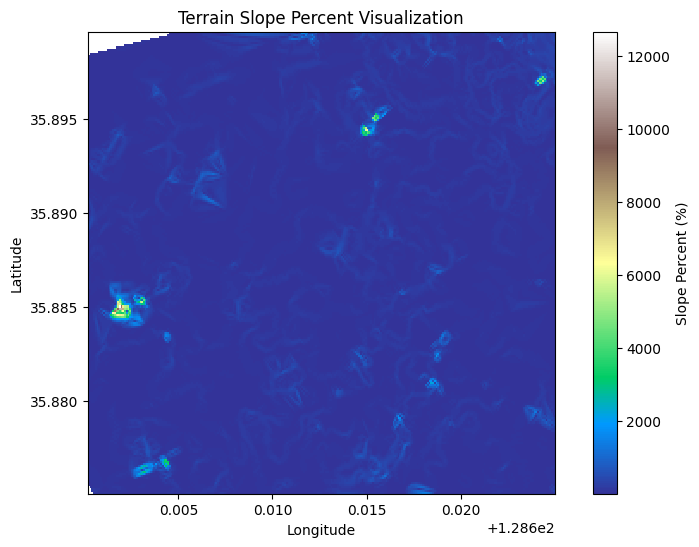

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 경사도 데이터 파일 불러오기
slope_data = np.load('/content/slope_data.npz')
slope_percent = slope_data['slope_percent']
x_min = slope_data['x_min']
x_max = slope_data['x_max']
y_min = slope_data['y_min']
y_max = slope_data['y_max']

# 데이터 시각화
plt.figure(figsize=(10, 6))
plt.title('Terrain Slope Percent Visualization')
plt.imshow(slope_percent, extent=[x_min, x_max, y_min, y_max], cmap='terrain', interpolation='none')
plt.colorbar(label='Slope Percent (%)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
def get_slope_at_location(latitude, longitude, data_file):
    # 데이터 로드
    data = np.load(data_file)
    slope_data = data['slope_percent']
    x_min, x_max, y_min, y_max = data['x_min'], data['x_max'], data['y_min'], data['y_max']

    # 경사도 데이터의 차원 확인
    nrows, ncols = slope_data.shape

    # 주어진 위도와 경도를 배열 인덱스로 변환
    row = int((latitude - y_min) / (y_max - y_min) * nrows)
    col = int((longitude - x_min) / (x_max - x_min) * ncols)

    # 인덱스가 범위를 벗어나는지 검사
    if row < 0 or row >= nrows or col < 0 or col >= ncols:
        return "Latitude or Longitude out of bounds."

    # 해당 위치의 경사도 반환
    return slope_data[row, col]

# 파일 경로와 검색할 위도 및 경도 지정
file_path = '/content/slope_data.npz'

latitude = 35.88
longitude = 128.61

# 함수 호출 및 출력
slope_at_location = get_slope_at_location(latitude, longitude, file_path)
print(f"({latitude}, {longitude})의 경사도: {slope_at_location:.2f} %.")

(35.88, 128.61)의 경사도: 116.04 %.


In [ ]:
import geopandas as gpd

forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
forest_cover_data

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((1098564.973 1757553.691, 1098436.325..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((1098161.540 1757601.763, 1098160.140..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((1098161.540 1757601.763, 1098158.093..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((1098546.934 1757870.126, 1098544.612..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((1098550.062 1757587.110, 1098542.506..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((1099396.860 1758220.715, 1099248.728..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((1098448.257 1758368.225, 1098448.925..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((1099140.293 1758056.136, 1099137.218..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((1097571.420 1758136.652, 1097566.921..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((1098588.753 1758927.013, 1098591.745..."


In [ ]:
# 초기 좌표계 설정 (좌표계: UTM-K(EPSG: 5179))
forest_cover_data.set_crs(epsg=5179, inplace=True)

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
forest_cover_data = forest_cover_data.to_crs(epsg=4326)

forest_cover_data

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((128.59098 35.80950, 128.58953 35.807..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((128.58652 35.80997, 128.58650 35.809..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((128.58652 35.80997, 128.58648 35.810..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((128.59082 35.81235, 128.59079 35.812..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((128.59082 35.80980, 128.59073 35.809..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((128.60027 35.81543, 128.59861 35.814..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((128.58979 35.81686, 128.58979 35.816..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((128.59741 35.81397, 128.59737 35.813..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((128.58005 35.81486, 128.58000 35.814..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((128.59141 35.82188, 128.59144 35.821..."


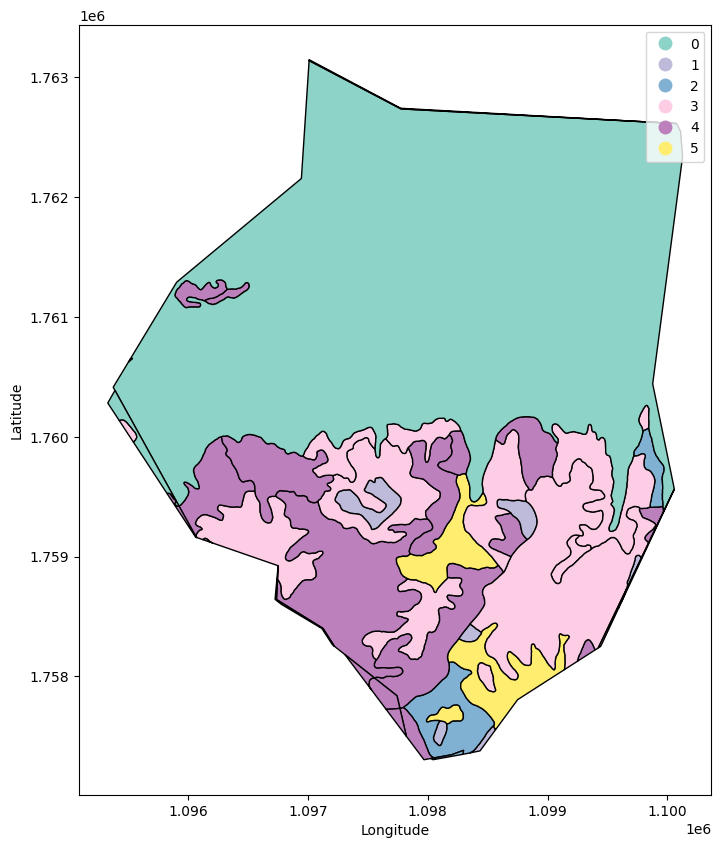

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 산림 커버 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')

# 영급 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# AGCLS_CD 컬럼을 기준으로 서로 다른 색상으로 시각화
forest_cover_data.plot(column='AGCLS_CD', ax=ax, legend=True, cmap='Set3', edgecolor='black')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

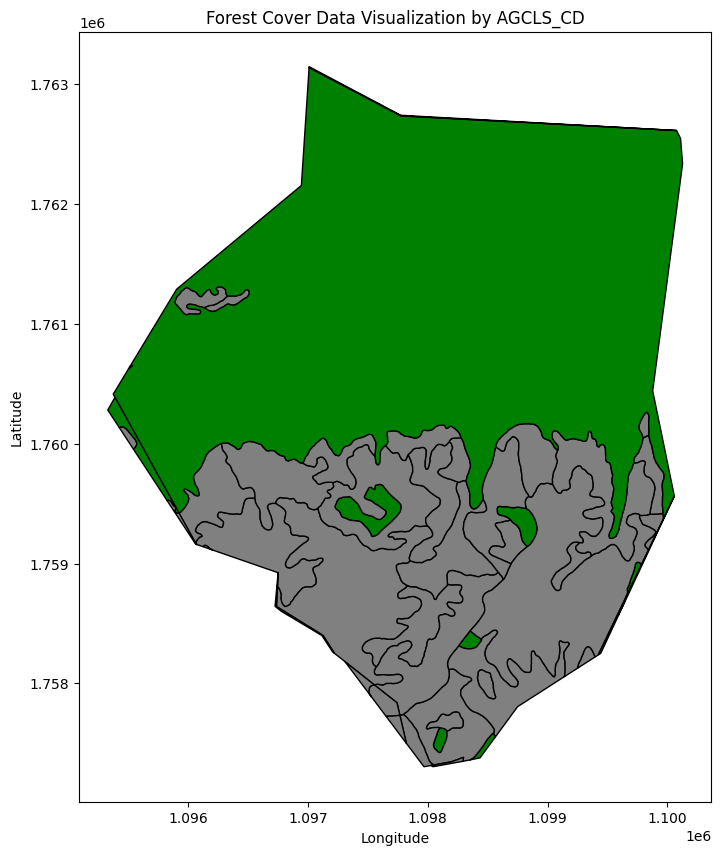

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 임상도 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')

# 색상 지정 함수
def assign_color(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'gray'

# AGCLS_CD 컬럼을 정수형으로 변환하고 색상 지정
forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color)

# 영급 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='black')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Forest Cover Data Visualization by AGCLS_CD')
plt.show()

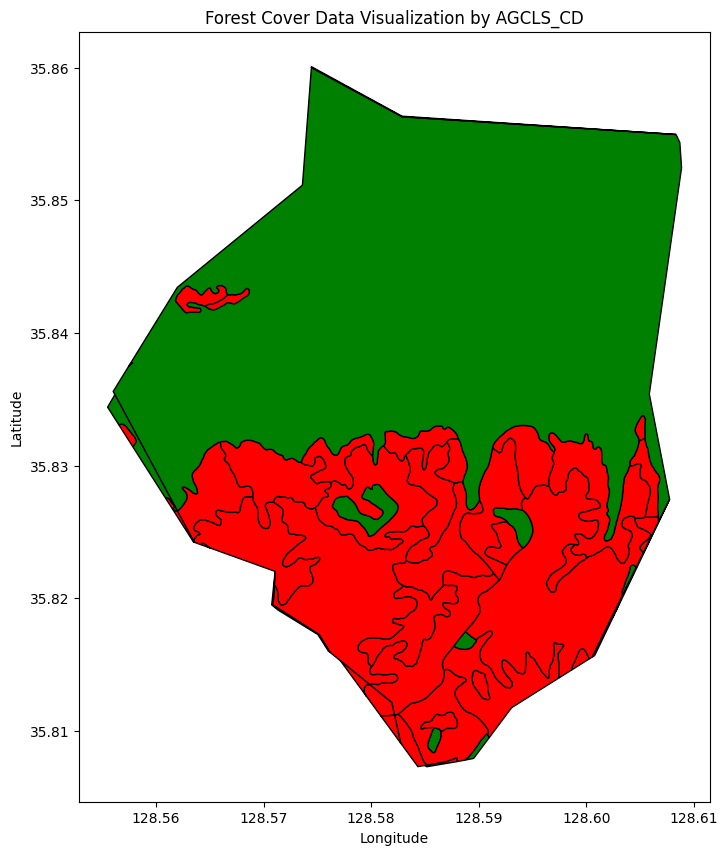

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 임상도 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')

# 초기 좌표계 설정 (좌표계: UTM-K(EPSG: 5179))
forest_cover_data.set_crs(epsg=5179, inplace=True)

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
forest_cover_data = forest_cover_data.to_crs(epsg=4326)

# 색상 지정 함수
def assign_color(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

# AGCLS_CD 컬럼을 정수형으로 변환하고 색상 지정
forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color)

# 영급 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='black')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Forest Cover Data Visualization by AGCLS_CD')
plt.show()

In [ ]:
forest_cover_data

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry,color
0,156495,M,1,1,None,M0-1,"POLYGON ((128.59098 35.80950, 128.58953 35.807...",green
1,156496,PK,1,1,None,PK0-1,"POLYGON ((128.58652 35.80997, 128.58650 35.809...",green
2,156498,H,3,5,A,H2-5A,"POLYGON ((128.58652 35.80997, 128.58648 35.810...",red
3,156503,D,2,3,C,D1-3C,"POLYGON ((128.59082 35.81235, 128.59079 35.812...",red
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((128.59082 35.80980, 128.59073 35.809...",red
5,156511,H,3,4,B,H2-4B,"POLYGON ((128.60027 35.81543, 128.59861 35.814...",red
6,156512,PR,1,1,None,PR0-1,"POLYGON ((128.58979 35.81686, 128.58979 35.816...",green
7,156513,H,3,5,A,H2-5A,"POLYGON ((128.59741 35.81397, 128.59737 35.813...",red
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((128.58005 35.81486, 128.58000 35.814...",red
9,156520,H,3,4,C,H2-4C,"POLYGON ((128.59141 35.82188, 128.59144 35.821...",red


In [ ]:
# 산림입지토양도 데이터 파일 경로
soil_survey_file = "/content/27.shp"

# Geopandas를 사용하여 shapefile 읽기
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

soil_survey_data

,CTPRV_CD,SGNG_CD,EMNDN_CD,CMBLC_ID,SBLT_ID,SMAR_NO,SLTP_CD,STQLT_CD,MPDMR_NO,STNDA_NMPL,...,KRPN_STIND,GNGN_LCLT,CNDST_PINE,ACTSM_STIN,JBLPN_STIN,MAP_NAM,MAP_NUM,SD_NM,SD_CD,geometry
0,27,27710,27710380,0000,0,002,02,None,358064,구지,...,15,0,11,18,13,대합,358064,대구광역시,27,"POLYGON ((128.39505 35.61743, 128.39510 35.617..."
1,27,27710,27710380,0000,0,001,01,None,358064,구지,...,12,0,8,15,10,대합,358064,대구광역시,27,"POLYGON ((128.39584 35.61697, 128.39600 35.616..."
2,27,27710,27710380,0000,0,002,02,None,358064,구지,...,15,0,11,18,13,대합,358064,대구광역시,27,"POLYGON ((128.39704 35.61577, 128.39701 35.615..."
3,27,27710,27710380,0000,0,002,02,None,358064,구지,...,15,0,11,18,13,대합,358064,대구광역시,27,"POLYGON ((128.40210 35.61790, 128.40218 35.617..."
4,27,27710,27710380,0000,0,003,24,None,358064,구지,...,0,0,0,0,0,대합,358064,대구광역시,27,"POLYGON ((128.40453 35.62140, 128.40455 35.621..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2924,47,47850,47850320,0000,0,064,01,None,358031,동명,...,12,0,7,13,0,칠곡,358031,경상북도,47,"POLYGON ((128.61183 35.99896, 128.61181 35.998..."
2925,47,47850,47850320,0000,0,064,01,None,358031,동명,...,12,0,7,13,0,다부,368153,대구광역시,27,"POLYGON ((128.61738 36.00618, 128.61732 36.005..."
2926,47,47850,47850320,0000,0,064,01,None,358031,동명,...,12,0,7,13,0,다부,368153,경상북도,47,"POLYGON ((128.61738 36.00618, 128.61732 36.005..."
2927,47,47850,47850320,0002,0,007,02,None,368153,칠곡002,...,12,10,9,14,11,다부,368153,대구광역시,27,"MULTIPOLYGON (((128.62194 36.00604, 128.62147 ..."


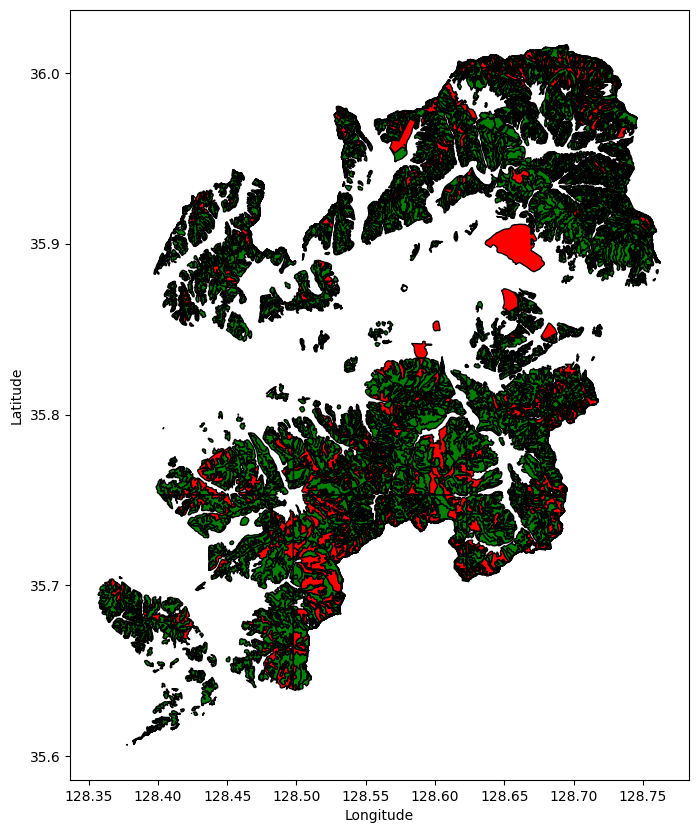

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# # 산림입지토양도 데이터 파일 경로
# soil_survey_file = "/content/27.shp"

# # Geopandas를 사용하여 shapefile 읽기
# soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 색상 지정 함수
def assign_color(sltp_cd):
    # '적윤', '약습'
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    # 91: 주거지, 95: 과수원, 97: 군사지역
    elif sltp_cd in ['91', '95', '97']:
        return 'red'
    else:
        return 'green'

# SLTP_CD 컬럼 사용하여 색상 지정
soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color)

# 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

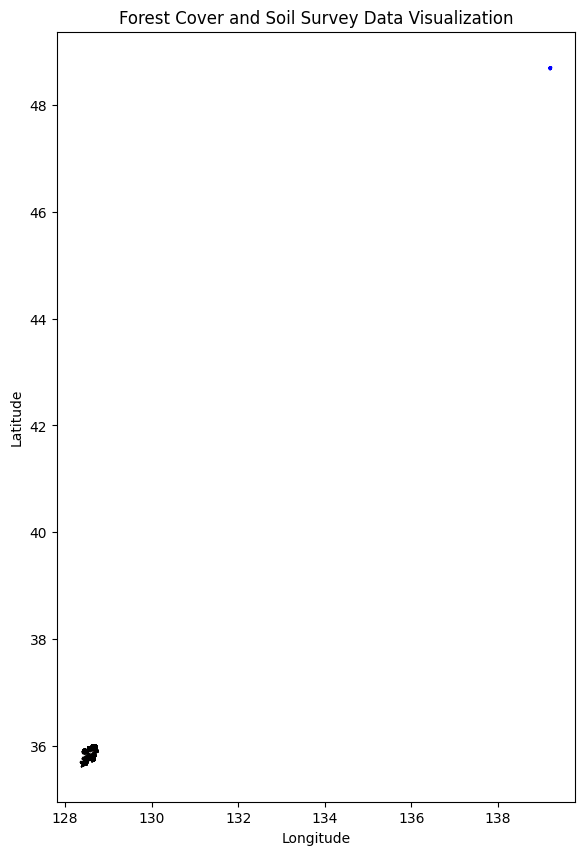

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 산림 커버 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
# 산림입지토양도 데이터 파일 경로
soil_survey_file = "/content/27.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 초기 좌표계 설정 (좌표계: UTM-K(EPSG: 5179))
forest_cover_data.set_crs(epsg=5174, inplace=True)
# 산림입지토양도 데이터는 이미 EPSG:5174 좌표계로 설정되어 있음

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
forest_cover_data = forest_cover_data.to_crs(epsg=4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

# 색상 지정 함수 (forest cover data)
def assign_color_forest(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

# AGCLS_CD 컬럼을 정수형으로 변환하고 색상 지정
forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color_forest)

# 색상 지정 함수 (soil survey data)
def assign_color_soil(sltp_cd):
    # '적윤', '약습'
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    # 91: 주거지, 97: 군사지역
    elif sltp_cd in ['91', '97']:
        return 'red'
    else:
        return 'green'

# SLTP_CD 컬럼 사용하여 색상 지정
soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color_soil)

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='blue')
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

ax.set_title('Forest Cover and Soil Survey Data Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

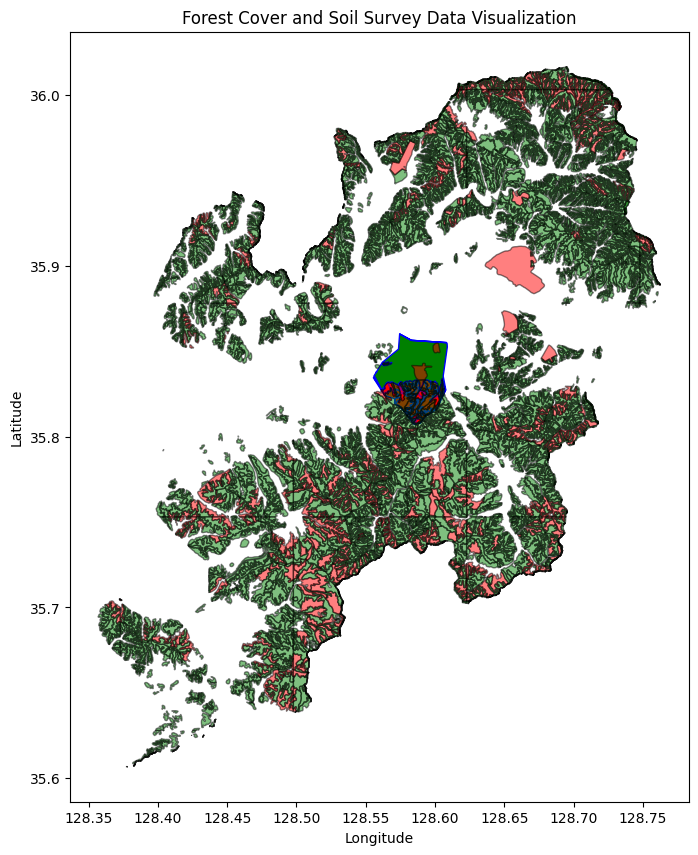

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 산림 커버 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
# 산림입지토양도 데이터 파일 경로
soil_survey_file = "/content/27.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 초기 좌표계 설정 (좌표계: UTM-K(EPSG: 5179))
forest_cover_data.set_crs(epsg=5179, inplace=True)
# 산림입지토양도 데이터는 이미 EPSG:5174 좌표계로 설정되어 있음

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
forest_cover_data = forest_cover_data.to_crs(epsg=4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

# 색상 지정 함수 (forest cover data)
def assign_color_forest(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

# AGCLS_CD 컬럼을 정수형으로 변환하고 색상 지정
forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color_forest)

# 색상 지정 함수 (soil survey data)
def assign_color_soil(sltp_cd):
    # '적윤', '약습'
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    # 91: 주거지, 97: 군사지역
    elif sltp_cd in ['91', '97']:
        return 'red'
    else:
        return 'green'

# SLTP_CD 컬럼 사용하여 색상 지정
soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color_soil)

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='blue')
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

ax.set_title('Forest Cover and Soil Survey Data Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

In [ ]:
!pip install contextily

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 37.0 MB/s eta 0:00:00


In [ ]:
# 표고점 데이터
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
print('표고점 좌표계 :', elevation_points.crs)

# 등고선 데이터
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')
print('등고선 좌표계 :', elevation_points.crs)

# 임상도 데이터
forest_cover_data = gpd.read_file("/content/TB_FGDI_FS_IM4000_27200.shp", encoding='euckr')
print('임상도 좌표계 :', forest_cover_data.crs)

# 산림입지토양도 데이터
soil_data = gpd.read_file("/content/27.shp", encoding='euckr')
print('산림입지토양도 좌표계 :', soil_data.crs)

표고점 좌표계 : EPSG:5187
등고선 좌표계 : EPSG:5187
임상도 좌표계 : None
산림입지토양도 좌표계 : PROJCS["PCS_ITRF2000_TM",GEOGCS["ITRF2000",DATUM["International_Terrestrial_Reference_Frame_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6656"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",600000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


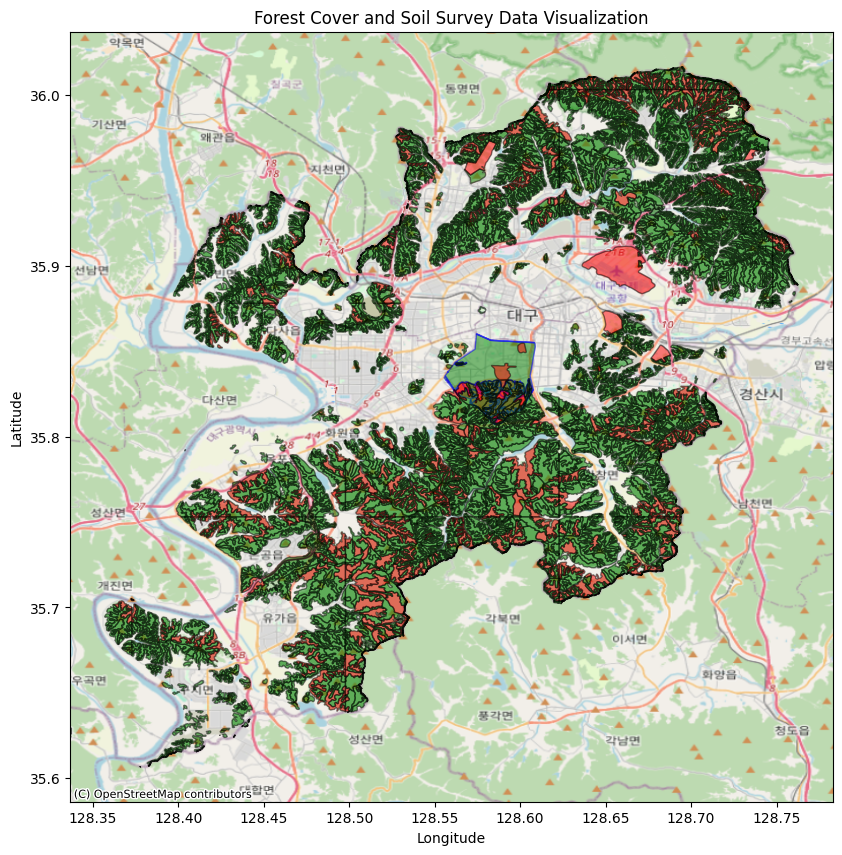

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import contextily as ctx

# 임상도 데이터 파일 경로
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
# 산림입지토양도 데이터 파일 경로
soil_survey_file = "/content/27.shp"

# Geopandas를 사용하여 shapefile 읽기
forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 초기 좌표계 설정 (좌표계: UTM-K(EPSG: 5179))
# 임상도 데이터의 경우 메타 데이터에 좌표계가 저장되어 있지 않아 초기 좌표계 설정 후 좌표계 변환 가능
# 수치지형도는 EPSG:5187 좌표계를 사용 / 산림입지토양도는 EPSG:5174 좌표계를 사용
forest_cover_data.set_crs(epsg=5179, inplace=True)

# 좌표계를 위도/경도 좌표계로 변환 (EPSG:4326)
forest_cover_data = forest_cover_data.to_crs(epsg=4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

# 색상 지정 함수 (forest cover data)
def assign_color_forest(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

# AGCLS_CD 컬럼을 정수형으로 변환하고 색상 지정
forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color_forest)

# 색상 지정 함수 (soil survey data)
def assign_color_soil(sltp_cd):
    # '적윤', '약습'
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    # 91: 주거지, 97: 군사지역
    elif sltp_cd in ['91', '97']:
        return 'red'
    else:
        return 'green'

# SLTP_CD 컬럼 사용하여 색상 지정
soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color_soil)

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='blue', alpha=0.5)
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

# 배경 타일 추가
ctx.add_basemap(ax, crs=forest_cover_data.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Forest Cover and Soil Survey Data Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

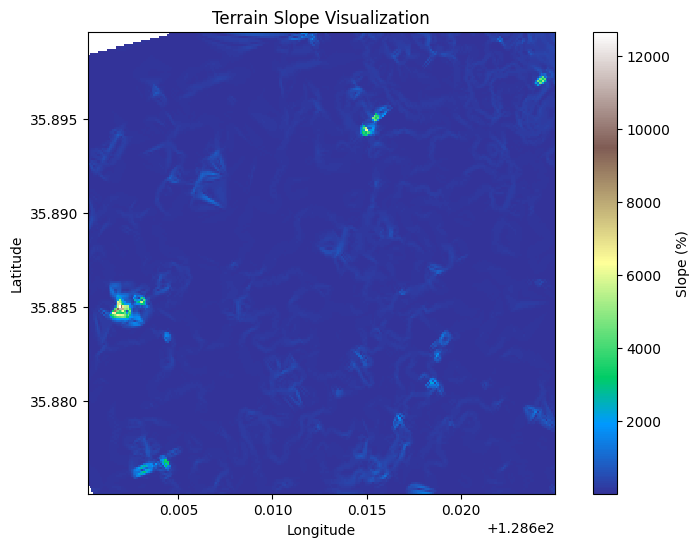

In [ ]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import griddata
from haversine import haversine, Unit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 데이터 로드
## 주의: 데이터가 한글로 되어 있기 때문에 encoding='euckr' 없으면 column 글자 깨짐
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')

# 데이터를 WGS 84 좌표계로 변환
elevation_points = elevation_points.to_crs(epsg=4326)
elevation_contours = elevation_contours.to_crs(epsg=4326)

# 등고선에서 고도 정보 추출 및 포인트로 변환
contour_points = elevation_contours.geometry.apply(lambda x: np.array(x.coords))
contour_elevations = np.repeat(elevation_contours['등고수치'], contour_points.apply(len))
contour_points = np.concatenate(contour_points.values)

# 표고점 데이터와 등고선 데이터 결합
all_points = np.vstack([contour_points, np.array(list(zip(elevation_points.geometry.x, elevation_points.geometry.y)))])
all_elevations = np.concatenate([contour_elevations, elevation_points['수치'].values])

# 각 방향의 실제 거리 계산
x_min, y_min, x_max, y_max = elevation_points.total_bounds
distance_x = haversine((y_min, x_min), (y_min, x_max), unit=Unit.METERS)
distance_y = haversine((y_min, x_min), (y_max, x_min), unit=Unit.METERS)

# 10m 간격으로 셀 수 계산
num_x_cells = int(distance_x / 10)
num_y_cells = int(distance_y / 10)

# 그리드 생성
## method 종류: 'nearest', 'linear', 'cubic'
## method='linear'는 선형 보간 방식을 사용한다는 것을 의미.
## 이 방법은 주변 점들 사이의 선형적인 관계를 기반으로 중간 값을 추정. 이는 비교적 부드러운 고도 표면을 생성
grid_x, grid_y = np.mgrid[x_min:x_max:num_x_cells*1j, y_min:y_max:num_y_cells*1j]
# grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='linear')
grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='cubic')
# grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='nearest')

# 경사도 계산
x, y = np.gradient(grid_z, axis=(0, 1), edge_order=1)
slope = np.sqrt(x**2 + y**2)
slope_degrees = np.arctan(slope) * (180 / np.pi)
slope_percent = np.tan(np.radians(slope_degrees)) * 100  # 경사도 백분율

# 경사도 데이터와 해당 좌표를 하나의 배열로 저장
coordinates_and_slope = np.zeros(slope_percent.shape, dtype=[('latitude', float), ('longitude', float), ('slope_percent', float)])

# 배열 크기에 따른 반복문 조정
for i in range(slope_percent.shape[0]):  # y축 크기
    for j in range(slope_percent.shape[1]):  # x축 크기
        lat = y_min + (i + 0.5) * (y_max - y_min) / slope_percent.shape[0]
        lon = x_min + (j + 0.5) * (x_max - x_min) / slope_percent.shape[1]
        coordinates_and_slope[i, j] = (lat, lon, slope_percent[i, j])

# 경사도 데이터와 위도, 경도 범위를 함께 저장
np.savez('/content/slope_data.npz', slope_percent=slope_percent, x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max)

# 시각화
extent = [x_min, x_max, y_min, y_max]
plt.figure(figsize=(10, 6))
plt.title('Terrain Slope Visualization')
plt.imshow(slope_percent, extent=extent, cmap='terrain', interpolation='none')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Slope (%)')

plt.show()

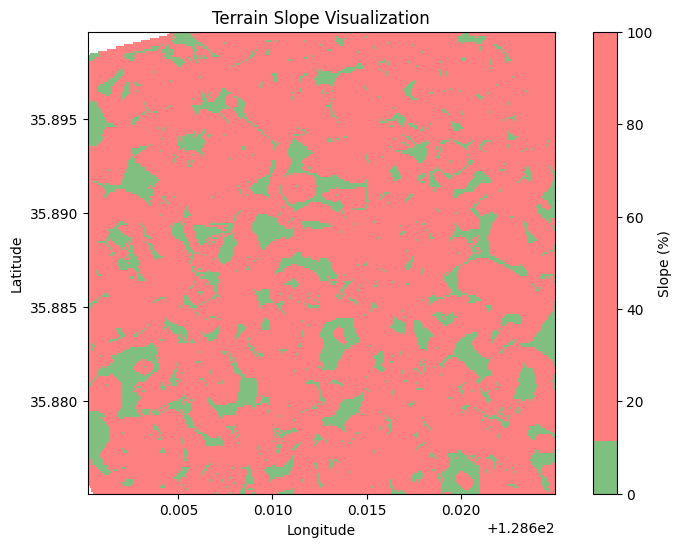

In [ ]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import griddata
from haversine import haversine, Unit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 데이터 로드
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')

# 데이터를 WGS 84 좌표계로 변환
elevation_points = elevation_points.to_crs(epsg=4326)
elevation_contours = elevation_contours.to_crs(epsg=4326)

# 등고선에서 고도 정보 추출 및 포인트로 변환
contour_points = elevation_contours.geometry.apply(lambda x: np.array(x.coords))
contour_elevations = np.repeat(elevation_contours['등고수치'], contour_points.apply(len))
contour_points = np.concatenate(contour_points.values)

# 표고점 데이터와 등고선 데이터 결합
all_points = np.vstack([contour_points, np.array(list(zip(elevation_points.geometry.x, elevation_points.geometry.y)))])
all_elevations = np.concatenate([contour_elevations, elevation_points['수치'].values])

# 각 방향의 실제 거리 계산
x_min, y_min, x_max, y_max = elevation_points.total_bounds
distance_x = haversine((y_min, x_min), (y_min, x_max), unit=Unit.METERS)
distance_y = haversine((y_min, x_min), (y_max, x_min), unit=Unit.METERS)

# 10m 간격으로 셀 수 계산
num_x_cells = int(distance_x / 10)
num_y_cells = int(distance_y / 10)

# 그리드 생성
grid_x, grid_y = np.mgrid[x_min:x_max:num_x_cells*1j, y_min:y_max:num_y_cells*1j]
grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='cubic')

# 경사도 계산
x, y = np.gradient(grid_z, axis=(0, 1), edge_order=1)
slope = np.sqrt(x**2 + y**2)
slope_degrees = np.arctan(slope) * (180 / np.pi)
slope_percent = np.tan(np.radians(slope_degrees)) * 100  # 경사도 백분율

# 사용자 정의 색상 맵 생성
colors = [(0.0, 'green'), (0.11, 'green'), (0.11, 'red'), (1.0, 'red')]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

# 시각화
extent = [x_min, x_max, y_min, y_max]
plt.figure(figsize=(10, 6))
plt.title('Terrain Slope Visualization')
plt.imshow(slope_percent, extent=extent, cmap=cmap, interpolation='none', vmin=0, vmax=100, alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Slope (%)')
plt.show()

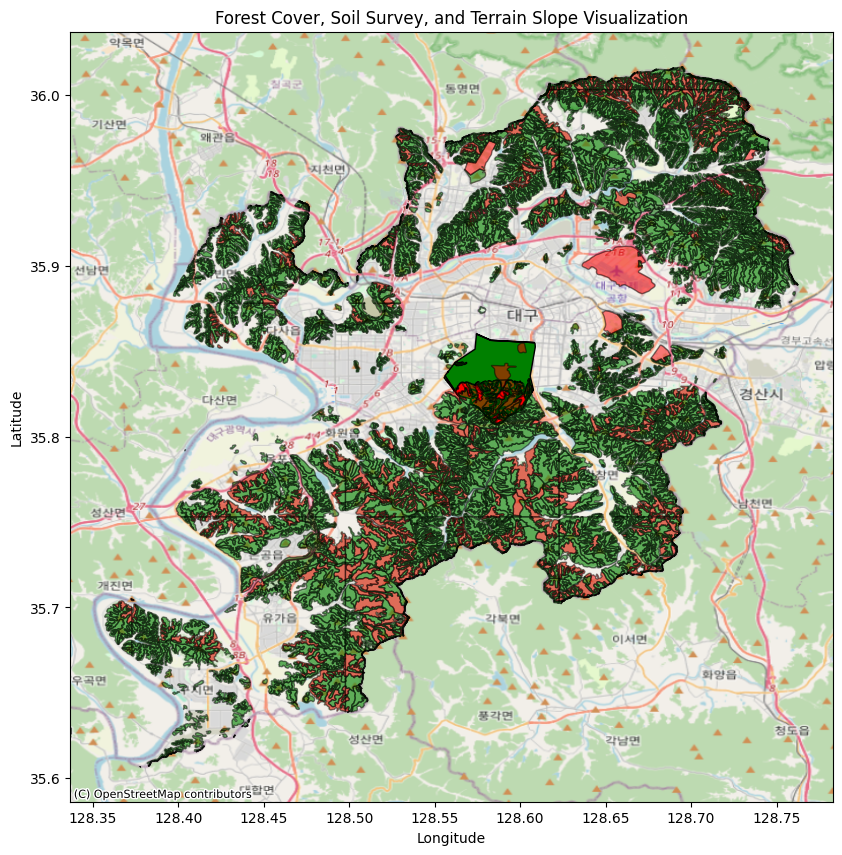

In [ ]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import griddata
from haversine import haversine, Unit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx

# 데이터 로드
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
soil_survey_file = "/content/27.shp"

forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 데이터를 WGS 84 좌표계로 변환
elevation_points = elevation_points.to_crs(epsg=4326)
elevation_contours = elevation_contours.to_crs(epsg=4326)
forest_cover_data.set_crs(epsg=5179, inplace=True)  # 임상도 데이터는 메타 데이터에 좌표계가 저장되어 있지 않아 기존 좌표계를 지정 후 변환해야 함.
forest_cover_data = forest_cover_data.to_crs(epsg=4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

# 등고선에서 고도 정보 추출 및 포인트로 변환
contour_points = elevation_contours.geometry.apply(lambda x: np.array(x.coords))
contour_elevations = np.repeat(elevation_contours['등고수치'], contour_points.apply(len))
contour_points = np.concatenate(contour_points.values)

# 표고점 데이터와 등고선 데이터 결합
all_points = np.vstack([contour_points, np.array(list(zip(elevation_points.geometry.x, elevation_points.geometry.y)))])
all_elevations = np.concatenate([contour_elevations, elevation_points['수치'].values])

# 각 방향의 실제 거리 계산
x_min, y_min, x_max, y_max = elevation_points.total_bounds
distance_x = haversine((y_min, x_min), (y_min, x_max), unit=Unit.METERS)
distance_y = haversine((y_min, x_min), (y_max, x_min), unit=Unit.METERS)

# 10m 간격으로 셀 수 계산
num_x_cells = int(distance_x / 10)
num_y_cells = int(distance_y / 10)

# 그리드 생성
grid_x, grid_y = np.mgrid[x_min:x_max:num_x_cells*1j, y_min:y_max:num_y_cells*1j]
grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='cubic')

# 경사도 계산
x, y = np.gradient(grid_z, axis=(0, 1), edge_order=1)
slope = np.sqrt(x**2 + y**2)
slope_degrees = np.arctan(slope) * (180 / np.pi)
slope_percent = np.tan(np.radians(slope_degrees)) * 100  # 경사도 백분율

# 사용자 정의 색상 맵 생성
colors = [(0.0, 'green'), (0.11, 'green'), (0.11, 'red'), (1.0, 'red')]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

def assign_color_forest(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color_forest)

def assign_color_soil(sltp_cd):
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    elif sltp_cd in ['91', '97']:
        return 'red'
    else:
        return 'green'

soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color_soil)

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 경사도 시각화
extent = [x_min, x_max, y_min, y_max]
ax.imshow(slope_percent, extent=extent, cmap=cmap, interpolation='none', vmin=0, vmax=100)

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='black')
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

# 배경 타일 추가
ctx.add_basemap(ax, crs=forest_cover_data.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Forest Cover, Soil Survey, and Terrain Slope Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

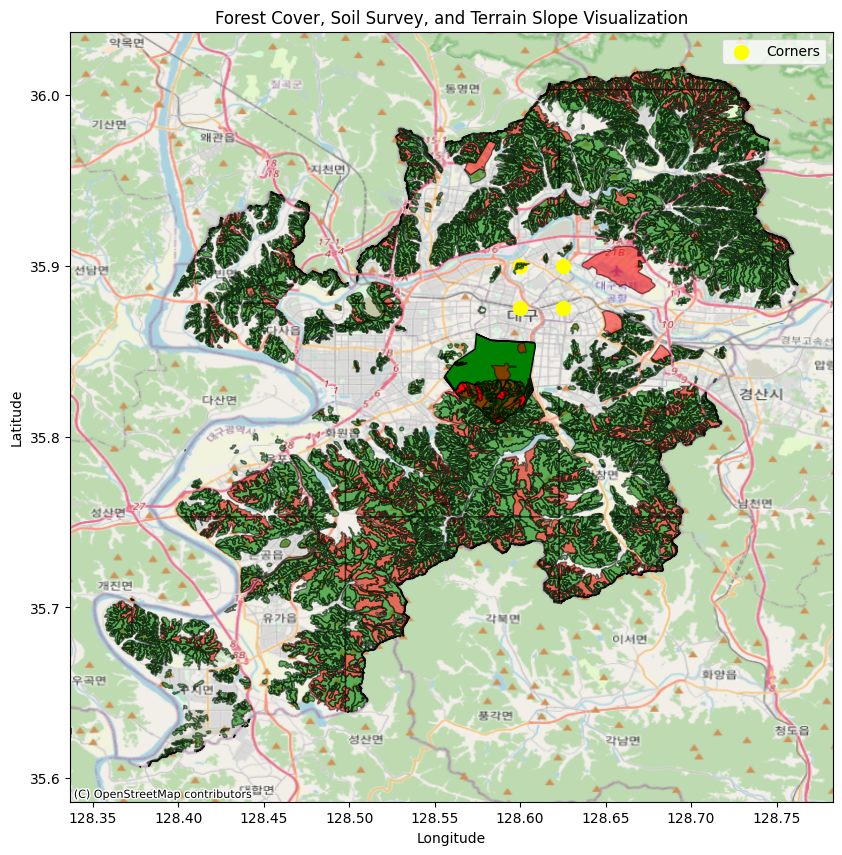

In [ ]:
# 사용자 정의 색상 맵 생성
colors = [(0.0, 'green'), (0.11, 'green'), (0.11, 'red'), (1.0, 'red')]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

# 경사도 데이터의 코너점 좌표
corners = np.array([[x_min, y_min], [x_max, y_min], [x_min, y_max], [x_max, y_max]])

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 경사도 시각화
extent = [x_min, x_max, y_min, y_max]
ax.imshow(slope_percent, extent=extent, cmap=cmap, interpolation='none', vmin=0, vmax=100)

# 코너점을 노란색 원으로 표시
ax.scatter(corners[:, 0], corners[:, 1], color='yellow', s=100, label='Corners')

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='black')
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

# 배경 타일 추가
ctx.add_basemap(ax, crs=forest_cover_data.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Forest Cover, Soil Survey, and Terrain Slope Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# 범례 추가
ax.legend()

plt.show()

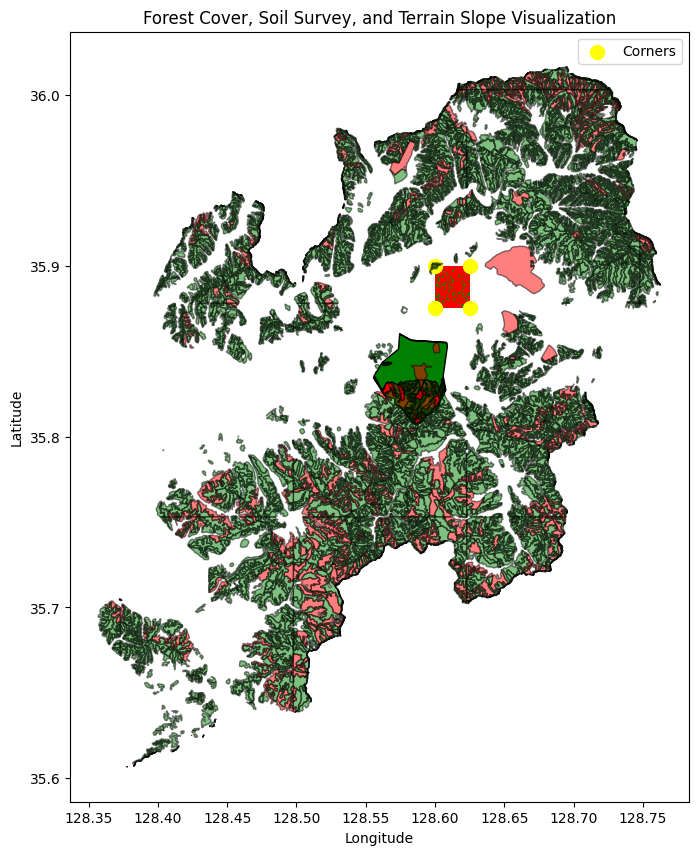

In [ ]:
import numpy as np
import geopandas as gpd
from scipy.interpolate import griddata
from haversine import haversine, Unit
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx

# 데이터 로드
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
elevation_contours = gpd.read_file("/content/N3L_F0010000.shp", encoding='euckr')
forest_cover_file = "/content/TB_FGDI_FS_IM4000_27200.shp"
soil_survey_file = "/content/27.shp"

forest_cover_data = gpd.read_file(forest_cover_file, encoding='euckr')
soil_survey_data = gpd.read_file(soil_survey_file, encoding='euckr')

# 데이터를 WGS 84 좌표계로 변환
elevation_points = elevation_points.to_crs(epsg=4326)
elevation_contours = elevation_contours.to_crs(epsg=4326)
forest_cover_data.set_crs(epsg=5179, inplace=True)  # 임상도 데이터는 메타 데이터에 좌표계가 저장되어 있지 않아 기존 좌표계를 지정 후 변환해야 함.
forest_cover_data = forest_cover_data.to_crs(epsg=4326)
soil_survey_data = soil_survey_data.to_crs(epsg=4326)

# 등고선에서 고도 정보 추출 및 포인트로 변환
contour_points = elevation_contours.geometry.apply(lambda x: np.array(x.coords))
contour_elevations = np.repeat(elevation_contours['등고수치'], contour_points.apply(len))
contour_points = np.concatenate(contour_points.values)

# 표고점 데이터와 등고선 데이터 결합
all_points = np.vstack([contour_points, np.array(list(zip(elevation_points.geometry.x, elevation_points.geometry.y)))])
all_elevations = np.concatenate([contour_elevations, elevation_points['수치'].values])

# 각 방향의 실제 거리 계산
x_min, y_min, x_max, y_max = elevation_points.total_bounds
distance_x = haversine((y_min, x_min), (y_min, x_max), unit=Unit.METERS)
distance_y = haversine((y_min, x_min), (y_max, x_min), unit=Unit.METERS)

# 10m 간격으로 셀 수 계산
num_x_cells = int(distance_x / 10)
num_y_cells = int(distance_y / 10)

# 그리드 생성
grid_x, grid_y = np.mgrid[x_min:x_max:num_x_cells*1j, y_min:y_max:num_y_cells*1j]
grid_z = griddata(all_points, all_elevations, (grid_x, grid_y), method='cubic')

# 경사도 계산
x, y = np.gradient(grid_z, axis=(0, 1), edge_order=1)
slope = np.sqrt(x**2 + y**2)
slope_degrees = np.arctan(slope) * (180 / np.pi)
slope_percent = np.tan(np.radians(slope_degrees)) * 100  # 경사도 백분율

# 사용자 정의 색상 맵 생성
colors = [(0.0, 'green'), (0.11, 'green'), (0.11, 'red'), (1.0, 'red')]
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)

def assign_color_forest(agcls_cd):
    if agcls_cd in [0, 1]:
        return 'green'
    else:
        return 'red'

forest_cover_data['AGCLS_CD'] = forest_cover_data['AGCLS_CD'].astype(int)
forest_cover_data['color'] = forest_cover_data['AGCLS_CD'].apply(assign_color_forest)

def assign_color_soil(sltp_cd):
    if sltp_cd in ['03', '04', '12', '19']:
        return 'red'
    elif sltp_cd in ['91', '97']:
        return 'red'
    else:
        return 'green'

soil_survey_data['color'] = soil_survey_data['SLTP_CD'].apply(assign_color_soil)

# 경사도 데이터의 코너점 좌표
corners = np.array([[x_min, y_min], [x_max, y_min], [x_min, y_max], [x_max, y_max]])

# 하나의 맵으로 데이터 시각화
fig, ax = plt.subplots(figsize=(10, 10))

# 경사도 시각화
extent = [x_min, x_max, y_min, y_max]
ax.imshow(slope_percent, extent=extent, cmap=cmap, interpolation='none', vmin=0, vmax=100)

# 코너점을 노란색 원으로 표시
ax.scatter(corners[:, 0], corners[:, 1], color='yellow', s=100, label='Corners')

# 산림 커버 데이터와 산림입지토양도 데이터를 같은 축에 플롯
forest_cover_data.plot(ax=ax, color=forest_cover_data['color'], edgecolor='black')
soil_survey_data.plot(ax=ax, color=soil_survey_data['color'], edgecolor='black', alpha=0.5)

# 배경 타일 추가
# ctx.add_basemap(ax, crs=forest_cover_data.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title('Forest Cover, Soil Survey, and Terrain Slope Visualization')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# 범례 추가
ax.legend()

plt.show()

In [ ]:
import geopandas as gpd

# 표고점 데이터
elevation_points = gpd.read_file("/content/N3P_F0020000.shp", encoding='euckr')
print('표고점 좌표계 :', elevation_points.crs)

표고점 좌표계 : EPSG:5187


In [ ]:
elevation_points

,수치,UFID,geometry
0,50.6,1000035803045F00210000000000000001,POINT (166136.718 364893.331)
1,36.5,1000035803045F00210000000000000002,POINT (165582.548 366416.492)
2,37.2,1000035803045F00210000000000000003,POINT (165673.890 366329.058)
3,37.4,1000035803045F00210000000000000004,POINT (166044.928 366947.213)
4,39.0,1000035803045F00210000000000000005,POINT (165762.082 366879.694)
...,...,...,...
321,58.8,1000035803045F00210000000000000322,POINT (163941.255 366308.269)
322,61.0,1000035803045F00210000000000000323,POINT (164473.447 366622.105)
323,52.9,1000035803045F00210000000000000324,POINT (164360.815 366577.431)
324,42.1,1000035803045F00210000000000000325,POINT (165299.340 366528.407)


In [ ]:
!ogrinfo -al -so /content/N3P_F0020000.shp

/bin/bash: line 1: ogrinfo: command not found


In [ ]:
import geopandas as gpd

# Load the shapefile
shapefile_path = "/content/TB_FGDI_FS_IM4000_27200.shp"
gdf = gpd.read_file(shapefile_path)

# Check the coordinate reference system (CRS) of the GeoDataFrame
gdf

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((1098564.973 1757553.691, 1098436.325..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((1098161.540 1757601.763, 1098160.140..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((1098161.540 1757601.763, 1098158.093..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((1098546.934 1757870.126, 1098544.612..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((1098550.062 1757587.110, 1098542.506..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((1099396.860 1758220.715, 1099248.728..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((1098448.257 1758368.225, 1098448.925..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((1099140.293 1758056.136, 1099137.218..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((1097571.420 1758136.652, 1097566.921..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((1098588.753 1758927.013, 1098591.745..."


In [ ]:
import fiona

# Load the shapefile using fiona
shapefile_path = "/content/TB_FGDI_FS_IM4000_27200.shp"

# Open the shapefile
with fiona.open(shapefile_path) as src:
    # Get the first few geometries to inspect
    geometries = [feature["geometry"] for feature in src][:5]

geometries

In [ ]:
gdf.set_crs(epsg=5179, inplace=True)  # 임상도 데이터는 메타 데이터에 좌표계가 저장되어 있지 않아 기존 좌표계를 지정 후 변환해야 함.

# 데이터를 5187 좌표계로 변환
crs_5187 = gdf.to_crs(epsg=5187)
crs_5187

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((163032.368 356984.573, 162901.014 35..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((162629.598 357038.836, 162628.104 35..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((162629.598 357038.836, 162626.221 35..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((163019.174 357301.342, 163016.845 35..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((163017.966 357018.227, 163010.336 35..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((163874.625 357638.969, 163725.010 35..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((162928.112 357801.042, 162928.742 35..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((163615.490 357478.291, 163612.384 35..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((162047.567 357582.864, 162043.131 35..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((163077.197 358357.777, 163080.156 35..."


In [ ]:
# 데이터를 4326 좌표계로 변환
crs_4326 = gdf.to_crs(epsg=4326)
crs_4326

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((128.59098 35.80950, 128.58953 35.807..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((128.58652 35.80997, 128.58650 35.809..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((128.58652 35.80997, 128.58648 35.810..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((128.59082 35.81235, 128.59079 35.812..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((128.59082 35.80980, 128.59073 35.809..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((128.60027 35.81543, 128.59861 35.814..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((128.58979 35.81686, 128.58979 35.816..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((128.59741 35.81397, 128.59737 35.813..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((128.58005 35.81486, 128.58000 35.814..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((128.59141 35.82188, 128.59144 35.821..."


In [ ]:
# 데이터를 5174 좌표계로 변환
crs_5174 = gdf.to_crs(epsg=5174)
crs_5174

,OBJ_ID,FIFTH_FRTP,DMCLS_CD,AGCLS_CD,DNST_CD,SMBL_CD,geometry
0,156495,M,1,1,None,M0-1,"POLYGON ((343726.679 257766.787, 343598.855 25..."
1,156496,PK,1,1,None,PK0-1,"POLYGON ((343322.788 257812.830, 343321.419 25..."
2,156498,H,3,5,A,H2-5A,"POLYGON ((343322.788 257812.830, 343319.316 25..."
3,156503,D,2,3,C,D1-3C,"POLYGON ((343707.019 258083.298, 343704.698 25..."
4,156504,PK,2,2,C,PK1-2C,"POLYGON ((343711.590 257800.148, 343704.054 25..."
5,156511,H,3,4,B,H2-4B,"POLYGON ((344555.608 258438.402, 344407.881 25..."
6,156512,PR,1,1,None,PR0-1,"POLYGON ((343605.751 258581.157, 343606.433 25..."
7,156513,H,3,5,A,H2-5A,"POLYGON ((344299.743 258272.428, 344296.676 25..."
8,156518,PL,2,3,C,PL1-3C,"POLYGON ((342729.632 258344.993, 342725.110 25..."
9,156520,H,3,4,C,H2-4C,"POLYGON ((343743.474 259140.955, 343746.480 25..."
